# BabyAI Training Demo

Run training on an existing BabyAI data split, compare validation accuracy before and after NeuPSL, and visualize action-sequence predictions.

In [10]:
from collections import defaultdict
from pathlib import Path
import json
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = Path.cwd()
if not (project_root / 'scripts').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
python = sys.executable

from data.loader import load_babyai_partition
from models.transformer import load_checkpoint

pretrain_size = 500
pretrain_valid_size = 100
train_size = 50
valid_size = 100
inference_size = 1000
batch_size = 64
ckpt_path = project_root / 'ckpt' / 'pretrained-babyai-transformer.pt'
result_dir = project_root / 'results' / f'babyai_train_{train_size}_infer_{inference_size}'
neupsl_model_path = result_dir / 'model.pt'

def run(command):
    command = [str(part) for part in command]
    print('$', ' '.join(command))
    completed = subprocess.run(command, cwd=project_root, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    completed.check_returncode()
    return completed

project_root

PosixPath('/Users/zmx/Desktop/neupsl-intent')

## 1. Load Existing BabyAI Data Split

In [11]:
data_root = project_root / 'data' / 'experiment_babyai'
pretrain_dir = data_root / 'pretrain' / f'size_{pretrain_size:04d}-valid_{pretrain_valid_size:04d}'
neupsl_train_dir = data_root / 'neupsl-train' / f'size_{train_size:04d}-valid_{valid_size:04d}'
inference_dir = data_root / 'inference' / f'size_{inference_size:04d}'

required_paths = [
    pretrain_dir / 'entity-data-map.txt',
    neupsl_train_dir / 'entity-data-map.txt',
    inference_dir / 'entity-data-map.txt',
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Generated split is incomplete. Missing: ' + ', '.join(str(path) for path in missing))

action_vocab = json.loads((data_root / 'action-vocab.json').read_text())
id_to_action = {value: key for key, value in action_vocab.items()}

print('Using existing generated data:')
for path in required_paths:
    print(' ', path.parent)
print('Configured sizes:', {
    'pretrain_size': pretrain_size,
    'pretrain_valid_size': pretrain_valid_size,
    'train_size': train_size,
    'valid_size': valid_size,
    'inference_size': inference_size,
})

Using existing generated data:
  /Users/zmx/Desktop/neupsl-intent/data/experiment_babyai/pretrain/size_0500-valid_0100
  /Users/zmx/Desktop/neupsl-intent/data/experiment_babyai/neupsl-train/size_0050-valid_0100
  /Users/zmx/Desktop/neupsl-intent/data/experiment_babyai/inference/size_1000
Configured sizes: {'pretrain_size': 500, 'pretrain_valid_size': 100, 'train_size': 50, 'valid_size': 100, 'inference_size': 1000}


## 2. Pretrained Transformer Checkpoint

In [12]:
if ckpt_path.exists():
    print(f'Using existing pretrained checkpoint: {ckpt_path}')
else:
    run([
        python, 'scripts/pretrain_transformer.py',
        '--pretrain-size', pretrain_size,
        '--pretrain-valid-size', pretrain_valid_size,
        '--output-path', ckpt_path,
    ])

history_path = ckpt_path.with_suffix('.history.json')
if history_path.exists():
    history = json.loads(history_path.read_text())
    display(history[-1])
else:
    print('No pretraining history file found for this checkpoint.')

Using existing pretrained checkpoint: /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt


{'epoch': 3,
 'is_best': False,
 'train_loss': 0.6747908272142358,
 'train_accuracy': 0.766057228301502,
 'train_examples': 14713,
 'valid_loss': 0.6376443666819285,
 'valid_accuracy': 0.7730769230769231,
 'valid_examples': 3380}

## 3. Validation Accuracy Before NeuPSL

In [13]:
def evaluate_checkpoint(model_path, data_dir, partition='valid', batch_size=256, device='auto'):
    if not Path(model_path).exists():
        return None
    if device == 'auto':
        if torch.cuda.is_available():
            device = 'cuda'
        elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
            device = 'mps'
        else:
            device = 'cpu'
    model = load_checkpoint(model_path, map_location=device).to(device)
    model.eval()
    token_ids, type_ids, labels = load_babyai_partition(data_dir, partition)
    predictions = []
    with torch.no_grad():
        for start in range(0, len(labels), batch_size):
            tokens = torch.as_tensor(token_ids[start:start + batch_size], dtype=torch.long, device=device)
            types = torch.as_tensor(type_ids[start:start + batch_size], dtype=torch.long, device=device)
            logits = model.logits(tokens, types)
            predictions.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
    predictions = np.asarray(predictions, dtype=int)
    labels = np.asarray(labels, dtype=int)
    return {
        'checkpoint': str(model_path),
        'partition': partition,
        'examples': int(len(labels)),
        'accuracy': float(np.mean(predictions == labels)),
        'predictions': predictions,
        'labels': labels,
    }

before_metrics = evaluate_checkpoint(ckpt_path, neupsl_train_dir, 'valid')
{key: value for key, value in before_metrics.items() if key not in {'predictions', 'labels'}}

{'checkpoint': '/Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt',
 'partition': 'valid',
 'examples': 693,
 'accuracy': 0.3564213564213564}

## 4. NeuPSL Fine-Tuning

In [14]:
init_mode = 'pretrained'  # choose 'scratch' or 'pretrained'
gradient_steps = 20
admm_iterations = 50

command = [
    python, 'scripts/neupsl_train.py',
    '--train-size', train_size,
    '--valid-size', valid_size,
    '--inference-size', inference_size,
    '--init-mode', init_mode,
    '--gradient-steps', gradient_steps,
    '--admm-iterations', admm_iterations,
    '--batch-size', batch_size,
]
if init_mode == 'pretrained':
    command.extend(['--pretrained-path', ckpt_path])
run(command)

$ /Users/zmx/.pyenv/versions/.neupsl_env/bin/python scripts/neupsl_train.py --train-size 50 --valid-size 100 --inference-size 1000 --init-mode pretrained --gradient-steps 20 --admm-iterations 50 --batch-size 64 --pretrained-path /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt
NeuPSL init mode: pretrained
Pretrained checkpoint: /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt
2879 [main] INFO  org.linqs.psl.runtime.Runtime  - PSL Runtime Version 2.4.0-aad67da
5154 [main] INFO  org.linqs.psl.util.RandUtils  - Using random seed: 59819964
5182 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding out model.
5333 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding complete.
5333 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Loading deep predicates.
12085 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding out model.
12096 [main] I

CompletedProcess(args=['/Users/zmx/.pyenv/versions/.neupsl_env/bin/python', 'scripts/neupsl_train.py', '--train-size', '50', '--valid-size', '100', '--inference-size', '1000', '--init-mode', 'pretrained', '--gradient-steps', '20', '--admm-iterations', '50', '--batch-size', '64', '--pretrained-path', '/Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt'], returncode=0, stdout="NeuPSL init mode: pretrained\nPretrained checkpoint: /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt\n2879 [main] INFO  org.linqs.psl.runtime.Runtime  - PSL Runtime Version 2.4.0-aad67da\n5154 [main] INFO  org.linqs.psl.util.RandUtils  - Using random seed: 59819964\n5182 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding out model.\n5333 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding complete.\n5333 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Loading deep predicates.\n12085 [ma

## 5. Validation Accuracy After NeuPSL

In [15]:
after_metrics = evaluate_checkpoint(neupsl_model_path, neupsl_train_dir, 'valid')
if after_metrics is None:
    raise FileNotFoundError(f'No NeuPSL-trained checkpoint found at {neupsl_model_path}. Run the NeuPSL cell first.')

comparison = {
    'before_neupsl_accuracy': before_metrics['accuracy'],
    'after_neupsl_accuracy': after_metrics['accuracy'],
    'delta': after_metrics['accuracy'] - before_metrics['accuracy'],
    'examples': after_metrics['examples'],
}
comparison

{'before_neupsl_accuracy': 0.3564213564213564,
 'after_neupsl_accuracy': 0.8874458874458875,
 'delta': 0.5310245310245311,
 'examples': 693}

## 6. Action Sequence Prediction Visualization

In [16]:
def load_jsonl(path):
    rows = []
    with Path(path).open() as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def predict_rows(model_path, rows, device='auto'):
    if device == 'auto':
        if torch.cuda.is_available():
            device = 'cuda'
        elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
            device = 'mps'
        else:
            device = 'cpu'
    model = load_checkpoint(model_path, map_location=device).to(device)
    model.eval()
    tokens = torch.as_tensor([row['token_ids'] for row in rows], dtype=torch.long, device=device)
    types = torch.as_tensor([row['type_ids'] for row in rows], dtype=torch.long, device=device)
    with torch.no_grad():
        probs = model(tokens, types).detach().cpu().numpy()
    pred_ids = np.argmax(probs, axis=1)
    return [id_to_action[int(index)] for index in pred_ids], probs

def choose_terminal_segment(rows, neural_preds, neupsl_preds, max_len=6, episode_index=0):
    episodes = defaultdict(list)
    for row, neural_pred, neupsl_pred in zip(rows, neural_preds, neupsl_preds):
        item = dict(row)
        item['neural_pred'] = neural_pred
        item['neupsl_pred'] = neupsl_pred
        episodes[row['episode_id']].append(item)

    episode_ids = sorted(episodes)
    episode_id = episode_ids[episode_index % len(episode_ids)]
    episode_rows = sorted(episodes[episode_id], key=lambda row: row['step_index'])
    segment_len = min(max_len, len(episode_rows))
    start = len(episode_rows) - segment_len
    return episode_rows[start:], start, episode_rows

valid_rows = load_jsonl(neupsl_train_dir / 'sequence-data-valid.jsonl')
neural_all_preds, neural_all_probs = predict_rows(ckpt_path, valid_rows)
neupsl_all_preds, neupsl_all_probs = predict_rows(neupsl_model_path, valid_rows)
segment, segment_start, episode = choose_terminal_segment(valid_rows, neural_all_preds, neupsl_all_preds, episode_index=0)
segment_len = len(segment)

neural_preds = [row['neural_pred'] for row in segment]
neupsl_preds = [row['neupsl_pred'] for row in segment]
{
    'episode_id': segment[0]['episode_id'],
    'shown_steps': [row['step_index'] for row in segment],
    'rows': [(row['step_index'], row['action'], neural, neupsl) for row, neural, neupsl in zip(segment, neural_preds, neupsl_preds)],
}

{'episode_id': 'babyai-opendoor-v0-00020',
 'shown_steps': [0, 1, 2, 3, 4, 5],
 'rows': [(0, 'forward', 'right', 'forward'),
  (1, 'right', 'left', 'right'),
  (2, 'forward', 'left', 'forward'),
  (3, 'forward', 'left', 'forward'),
  (4, 'left', 'left', 'left'),
  (5, 'toggle', 'left', 'toggle')]}

**Visualization Legend**

- `true`: the expert BabyAIBot next action stored in the validation split.
- `Neural`: the pretrained Transformer prediction before NeuPSL fine-tuning.
- `NeuPSL`: the neural checkpoint prediction after NeuPSL fine-tuning, loaded from `results/.../model.pt`.
- Green titles mean the `NeuPSL` prediction matches `true`; red titles mean it does not.

This panel shows the last few steps of one validation episode so the path toward the target is easy to read. It visualizes the fine-tuned neural checkpoint; parsing PSL-fused `Action` atoms would be a separate inference visualization.

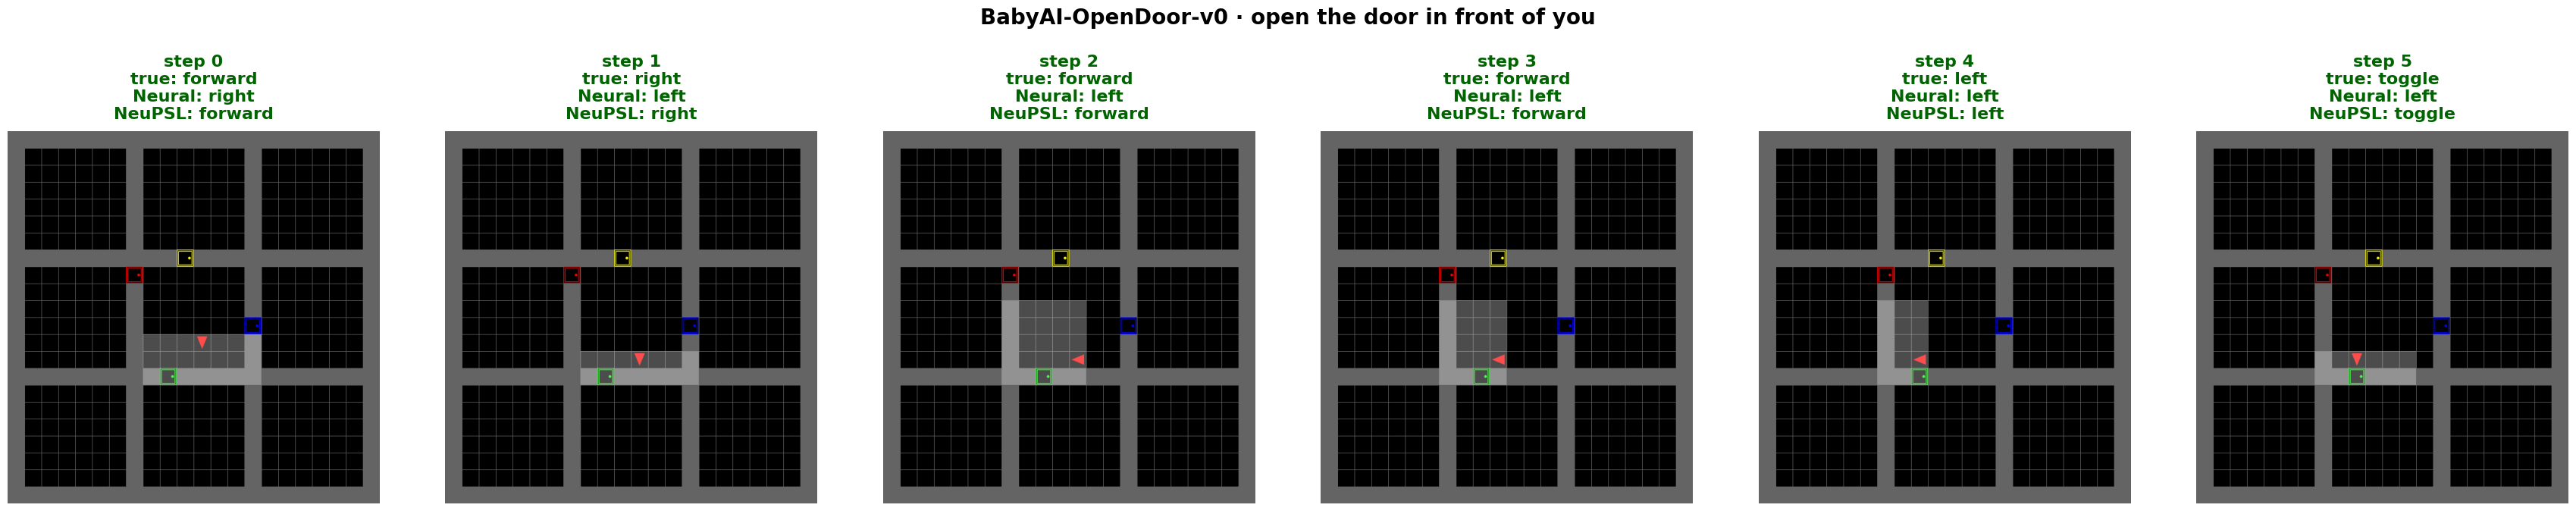

In [17]:
def episode_seed(episode_id):
    match = re.search(r'(\d+)$', episode_id)
    if not match:
        raise ValueError(f'Cannot parse seed from {episode_id}')
    return int(match.group(1))

def render_episode_frames(row, frame_count):
    import gymnasium as gym
    import minigrid  # noqa: F401
    from minigrid.utils.baby_ai_bot import BabyAIBot

    env = gym.make(row['env_id'], render_mode='rgb_array')
    env.reset(seed=episode_seed(row['episode_id']))
    bot = BabyAIBot(env)
    frames = []
    last_action = None
    for frame_index in range(frame_count):
        frames.append(env.render())
        action = bot.replan(last_action)
        _, _, terminated, truncated, _ = env.step(action)
        last_action = action
        if terminated or truncated:
            break
    env.close()
    return frames

frames = render_episode_frames(episode[0], segment_start + segment_len)
frames = frames[segment_start:segment_start + segment_len]

fig, axes = plt.subplots(1, len(segment), figsize=(5.8 * len(segment), 6.2))
if len(segment) == 1:
    axes = [axes]
for ax, frame, row, neural, neupsl in zip(axes, frames, segment, neural_preds, neupsl_preds):
    correct_neupsl = neupsl == row['action']
    ax.imshow(frame)
    title = f"step {row['step_index']}\ntrue: {row['action']}\nNeural: {neural}\nNeuPSL: {neupsl}"
    ax.set_title(
        title,
        color='darkgreen' if correct_neupsl else 'darkred',
        fontsize=16,
        fontweight='bold',
        pad=12,
    )
    ax.axis('off')
fig.suptitle(f"{segment[0]['env_id']} · {segment[0]['mission']}", y=1.08, fontsize=20, fontweight='bold')
plt.tight_layout()

## 7. Summarize Results

In [18]:
run([
    python, 'scripts/evaluate.py',
    '--train-size', train_size,
    '--valid-size', valid_size,
    '--inference-size', inference_size,
])

$ /Users/zmx/.pyenv/versions/.neupsl_env/bin/python scripts/evaluate.py --train-size 50 --valid-size 100 --inference-size 1000
{
  "evaluations": [
    "Evaluator: CategoricalEvaluator, Predicate: ACTION, Results -- Categorical Accuracy: 0.838774"
  ],
  "learned_rules": [
    {
      "ruleIndex": 0,
      "squared": true,
      "text": "0.9514204: NEURALACTION(S, A) >> ACTION(S, A) ^2",
      "weight": 0.9514204
    },
    {
      "ruleIndex": 1,
      "squared": true,
      "text": "1.0: INVALIDACTION(S, A) >> ~( ACTION(S, A) ) ^2",
      "weight": 1.0
    },
    {
      "ruleIndex": 2,
      "squared": true,
      "text": "0.98209316: PLAUSIBLEACTION(S, A) >> ACTION(S, A) ^2",
      "weight": 0.98209316
    },
    {
      "ruleIndex": 3,
      "squared": false,
      "text": "1.0 * ACTION(S, +A) = 1.0 .",
      "weight": null
    }
  ],
  "num_atoms": 98644
}



CompletedProcess(args=['/Users/zmx/.pyenv/versions/.neupsl_env/bin/python', 'scripts/evaluate.py', '--train-size', '50', '--valid-size', '100', '--inference-size', '1000'], returncode=0, stdout='{\n  "evaluations": [\n    "Evaluator: CategoricalEvaluator, Predicate: ACTION, Results -- Categorical Accuracy: 0.838774"\n  ],\n  "learned_rules": [\n    {\n      "ruleIndex": 0,\n      "squared": true,\n      "text": "0.9514204: NEURALACTION(S, A) >> ACTION(S, A) ^2",\n      "weight": 0.9514204\n    },\n    {\n      "ruleIndex": 1,\n      "squared": true,\n      "text": "1.0: INVALIDACTION(S, A) >> ~( ACTION(S, A) ) ^2",\n      "weight": 1.0\n    },\n    {\n      "ruleIndex": 2,\n      "squared": true,\n      "text": "0.98209316: PLAUSIBLEACTION(S, A) >> ACTION(S, A) ^2",\n      "weight": 0.98209316\n    },\n    {\n      "ruleIndex": 3,\n      "squared": false,\n      "text": "1.0 * ACTION(S, +A) = 1.0 .",\n      "weight": null\n    }\n  ],\n  "num_atoms": 98644\n}\n', stderr='')